In [41]:
import json

from utils.utils import load_data, scale_data, evaluate_model, save_results
from utils.preprocessing import load_and_prepare_kfold_data
from utils.plotting import plot_rmse_vs_k, plot_residuals
from utils.train import train_knn,train_svr

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline

In [2]:
X_train_cv, X_val_cv, X_test_cv, y_train_cv, y_val_cv, y_test_cv = load_data()
X_train_cv, X_val_cv, X_test_cv, scaler = scale_data(X_train_cv, X_val_cv, X_test_cv)

       cement    slag  fly_ash   water  superplasticizer  coarse_agg  \
count  603.00  603.00   603.00  603.00            603.00      603.00   
mean     0.05    0.37     0.45   -0.13             -0.01        0.04   
std      0.68    0.64     0.54    0.82              0.60        0.80   
min     -1.14   -0.14     0.00   -2.42             -0.60       -1.72   
25%     -0.51   -0.14     0.00   -0.72             -0.60       -0.37   
50%      0.00    0.00     0.00    0.00              0.00        0.00   
75%      0.49    0.86     1.00    0.28              0.40        0.63   
max      1.71    2.55     1.69    1.94              2.62        1.72   

       fine_agg     age  
count    603.00  603.00  
mean      -0.06    0.44  
std        0.81    1.45  
min       -1.83   -0.59  
25%       -0.51   -0.38  
50%        0.00    0.00  
75%        0.49    0.62  
max        2.09    7.41  


## Algorithm testing using single cross validation set


Best k: 3, Val RMSE: 7.9387


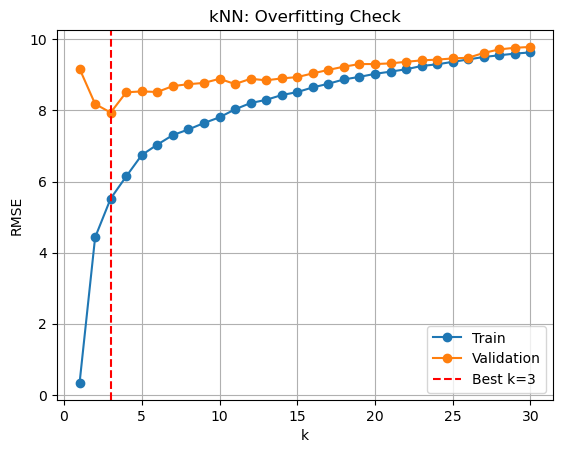

In [3]:

train_rmse_list = []
val_rmse_list = []
k_range = range(1, 31)

for k in k_range:
    knn_cv = KNeighborsRegressor(n_neighbors=k)
    knn_cv.fit(X_train_cv, y_train_cv)
    
    train_rmse_list.append(np.sqrt(mean_squared_error(y_train_cv, knn_cv.predict(X_train_cv))))
    val_rmse_list.append(np.sqrt(mean_squared_error(y_val_cv, knn_cv.predict(X_val_cv))))


best_k = k_range[np.argmin(val_rmse_list)]
print(f"Best k: {best_k}, Val RMSE: {min(val_rmse_list):.4f}")

plt.plot(k_range, train_rmse_list, label='Train', marker='o')
plt.plot(k_range, val_rmse_list,   label='Validation', marker='o')
plt.axvline(x=best_k, color='red', linestyle='--', label=f'Best k={best_k}')
plt.xlabel('k')
plt.ylabel('RMSE')
plt.title('kNN: Overfitting Check')
plt.legend()
plt.grid(True)
plt.show()

In [4]:
knn_cv = KNeighborsRegressor(n_neighbors=best_k)
knn_cv.fit(X_train_cv, y_train_cv)

,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [5]:
y_pred_train_cv = knn_cv.predict(X_train_cv)
y_pred_cv = knn_cv.predict(X_test_cv)

print("RMSE training:", np.sqrt(mean_squared_error(y_train_cv, y_pred_train_cv)))
print("R² training:", r2_score(y_train_cv, y_pred_train_cv))

print("RMSE testing:", np.sqrt(mean_squared_error(y_test_cv, y_pred_cv)))
print("R² testing:", r2_score(y_test_cv, y_pred_cv))

RMSE training: 5.522301655568156
R² training: 0.8830576797715924
RMSE testing: 8.98614193587343
R² testing: 0.7414139219425143


# Data Loading


## Setup Cell

In [54]:
json_path = "config.json"
with open(json_path) as f:
    config = json.load(f)

filepath_raw = config["filepath"]
filepath_engineered = config["engineered_filepath"]
algorithm  = 'knn'       # 'knn', 'svr', 'nusvr'
experiment = 'engineered'  # 'engineered', 'non-engineered'
target = config["target"]
seed = 123


## Experiments Cell

In [55]:
experiments = {
    'non-engineered': {
        'filepath': filepath_raw,
        'target':   target,
        'columns':  ["cement", "slag", "fly_ash", "water",
                     "superplasticizer", "coarse_agg", "fine_agg", "age", "strength"],
    },
    'engineered': {
        'filepath': filepath_engineered,
        'target':   target,
        'columns':  None,
    },
}

exp = experiments[experiment]
results_file = f'{algorithm}_{experiment}_results.csv'

#load data
X_train_kf, X_test_kf, y_train_kf, y_test_kf = load_and_prepare_kfold_data(**exp,random_state=seed)  #seed = 0,42,123

## kNN with k-folds validation

Best k (K-Fold): 2, val RMSE: 7.9124


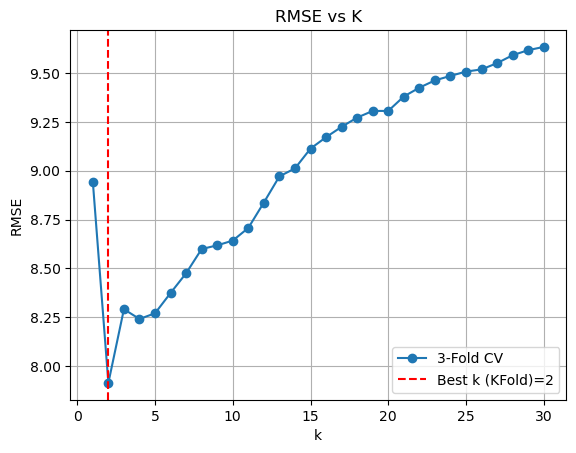


kNN Results:
Total Samples : 1002
Test Samples  : 201
MAE      : 5.0298
RMSE     : 6.8149
R        : 0.9032
R²       : 0.8158


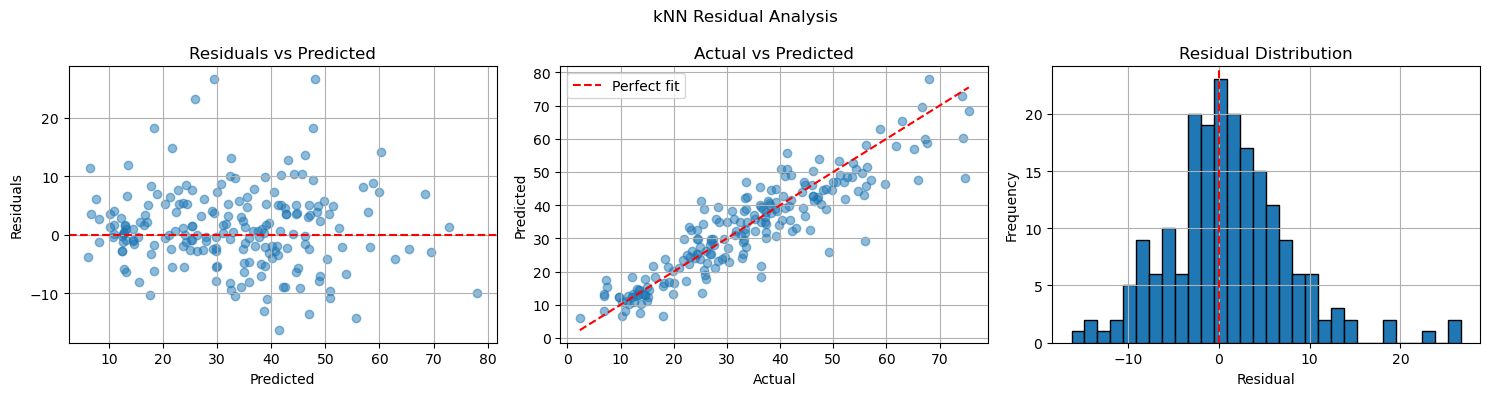

Results saved to results/knn_engineered_results.csv
minkowski


In [58]:
if algorithm == 'knn':
    k_cfg = config["knn"]["grid"]
    k_range = range(k_cfg["k_range"]["start"], k_cfg["k_range"]["stop"])
    metric = config["knn"]["metric"][2]
    p = config["knn"]['grid']["p"][2]   #change to 2 for p = 3


    best_k_kfold, min_RMSE, kfold_rmse_list, final_pipeline = train_knn(
        X_train_kf, y_train_kf, metric,
        k_range=k_range,
        scaler_type=config["scaler"]
    )
    plot_rmse_vs_k(k_range, kfold_rmse_list, best_k_kfold)

    final_pipeline = Pipeline([
        ('scaler', RobustScaler()),
        ('knn_kf', KNeighborsRegressor(n_neighbors=best_k_kfold, metric=metric,p = p))
    ])
    final_pipeline.fit(X_train_kf, y_train_kf)

    results = evaluate_model('kNN',
                             y_train_kf, final_pipeline.predict(X_train_kf),
                             y_test_kf,  final_pipeline.predict(X_test_kf))
    plot_residuals('kNN', y_test_kf, final_pipeline.predict(X_test_kf))
    save_results(results, results_file)
    print(metric)

# SVR and nuSVR 

[NuSVR] Best params: {'svr__C': 128, 'svr__kernel': 'rbf', 'svr__nu': 0.7}
[NuSVR] Best CV RMSE: 6.5128
[NuSVR] Train RMSE:   5.5367
[NuSVR] Train R²:     0.8855

nuSVR Results:
Total Samples : 1002
Test Samples  : 201
MAE      : 4.1645
RMSE     : 5.7441
R        : 0.9323
R²       : 0.8692


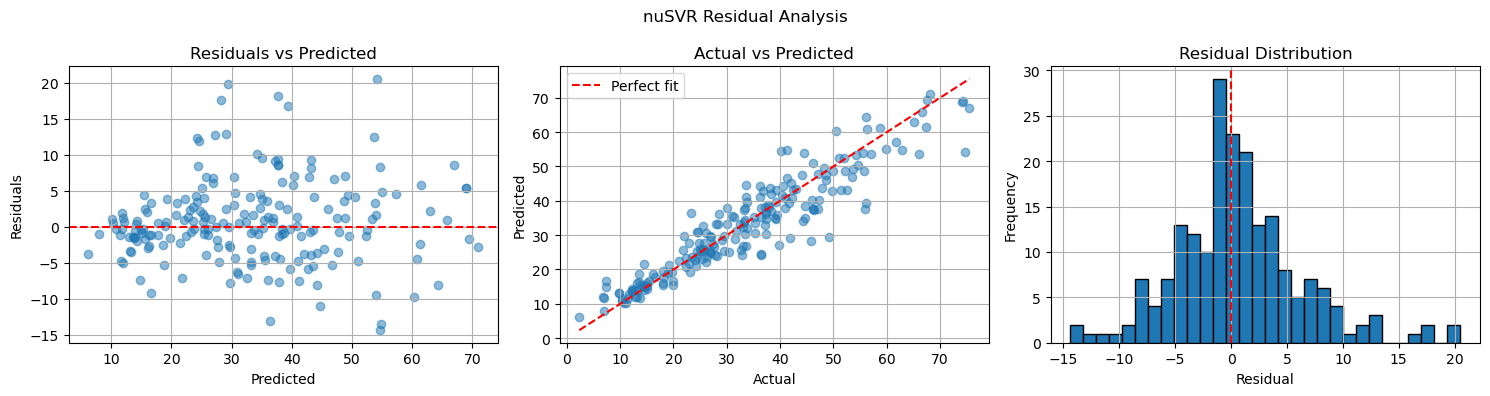

Results saved to results/nusvr_engineered_results.csv
seed:  123


In [50]:

if algorithm in ('svr', 'nusvr'):
    

    svr_type    = config[algorithm]["model_type"]
    scaler_type = "StandardScaler"

    best_svr, params_svr, rmse_svr = train_svr(
        X_train_kf, y_train_kf,
        svr_type=svr_type,
        scaler_type=scaler_type,
        json_path=json_path
    )

    y_pred_train_kf = best_svr.predict(X_train_kf)
    y_pred_test_kf  = best_svr.predict(X_test_kf)

    label = 'SVR' if algorithm == 'svr' else 'nuSVR'
    results = evaluate_model(label,
                             y_train_kf, y_pred_train_kf,
                             y_test_kf,  y_pred_test_kf)
    plot_residuals(label, y_test_kf, y_pred_test_kf)
    save_results(results, results_file)
    print("seed: " , seed)